In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import model_selection
from sklearn.model_selection import cross_val_score
from scipy.stats import pearsonr 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [218]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00265/CASP.csv')
df.shape

(45730, 10)

In [219]:
df.describe()
df.ffill(axis = 0) 
df.ffill(axis = 1)

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102.0,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39.0,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29.0,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70.0,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41.0,39.9147
...,...,...,...,...,...,...,...,...,...,...
45725,3.762,8037.12,2777.68,0.34560,64.3390,1.105797e+06,112.7460,3384.21,84.0,36.8036
45726,6.521,7978.76,2508.57,0.31440,75.8654,1.116725e+06,102.2770,3974.52,54.0,36.0470
45727,10.356,7726.65,2489.58,0.32220,70.9903,1.076560e+06,103.6780,3290.46,46.0,37.4718
45728,9.791,8878.93,3055.78,0.34416,94.0314,1.242266e+06,115.1950,3421.79,41.0,35.6045


In [220]:
# Creating new copies of data
data=df.copy().drop("RMSD" , axis = 1 )
label = df["RMSD"]
#Split training set and testing set
X_train, X_test, y_train, y_test = train_test_split(data,label,test_size=0.2)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of X_train:", y_train.shape)
print("Shape of X_test:", y_test.shape)

Shape of X_train: (36584, 9)
Shape of X_test: (9146, 9)
Shape of X_train: (36584,)
Shape of X_test: (9146,)


In [221]:
#linear Regression model
lr = LinearRegression()
#Train Data set 
lr.fit(X_train, y_train)
#Predict test data
test_pred = lr.predict(X_test)

actual target value predicted value

5653      7.915
38766     1.657
9885     18.644
4852     10.829
20878    12.644
          ...  
39417     1.736
20178     4.402
21507     0.731
12553     1.436
8735      2.793
Name: RMSD, Length: 9146, dtype: float64 [9.0941717  4.20721369 9.91493218 ... 4.12754184 6.47822307 4.70003428]


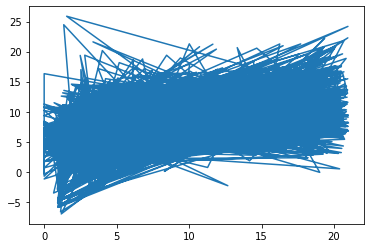

In [222]:
print("actual target value" , "predicted value\n")
print(y_test, test_pred)
plt.plot(y_test, test_pred)

In [223]:
#mean square error
test_mse = mean_squared_error(y_test, test_pred)
#mean absolute error
test_mae = mean_absolute_error(y_test,test_pred)
#root mean square error
test_rmse = np.round(np.sqrt(test_mse),2)
                     
print('Mean Absolute Error: %0.2f' % test_mse)
print('Mean Squared Error: %0.2f' % test_mae)
print('Root Mean Squared Error: %0.2f' % test_rmse)

Mean Absolute Error: 27.33
Mean Squared Error: 4.40
Root Mean Squared Error: 5.23


In [224]:
#function for PEARSON CORRELATION
def pearcor(list1, list2):
    corr, _ = pearsonr(list1, list2) 
    print('Pearsons correlation: %.3f\n' % corr)
    
#literate through all colums for finding PEARSON CORRELATION
for col in df.columns :
    if(col!="RMSD"):
        print("RMSD , ",col , ":")
        pearcor(df["RMSD"], df[col])

RMSD ,  F1 :
Pearsons correlation: -0.015

RMSD ,  F2 :
Pearsons correlation: 0.157

RMSD ,  F3 :
Pearsons correlation: 0.374

RMSD ,  F4 :
Pearsons correlation: -0.170

RMSD ,  F5 :
Pearsons correlation: -0.014

RMSD ,  F6 :
Pearsons correlation: -0.036

RMSD ,  F7 :
Pearsons correlation: -0.003

RMSD ,  F8 :
Pearsons correlation: 0.000

RMSD ,  F9 :
Pearsons correlation: 0.063



In [225]:
# -1 : perfectly negative linear relationship
#  0 : no relationship
# +1 : perfectly positive linear relationship

# .1 < | r | < .3   small / weak correlation
# .3 < | r | < .5   medium / moderate correlation
# .5 < | r |        large / strong correlation

#if -0.03 < corrilation < 0.03 i will consder it don't have relationship 

# F1, has no relationship
# F2, positive linear relationship with small / weak correlation
# F3, positive linear relationship with medium / moderate correlation
# F4, negative linear relationship with small / weak correlation
# F5, has no relationship
# F6, negative linear relationship
# F7, has no relationship
# F8, has no relationship
# F9, positive linear relationship 


# so I select F2,F3,F4

In [226]:
# Creating new copies of Stratified Train and Test data
data_new=df[["F2","F3","F4","F6","F9"]]
label_new = df["RMSD"]

In [227]:
data_new

,F2,F3,F4,F6,F9
0,4305.35,0.31754,162.1730,215.3590,27.0302
1,1623.16,0.26213,53.3894,87.2024,38.5468
2,1726.28,0.22343,67.2887,81.7913,38.8119
3,2368.25,0.28111,67.8325,109.4390,39.0651
4,1736.94,0.23280,52.4123,94.5234,39.9147
...,...,...,...,...,...
45725,2777.68,0.34560,64.3390,112.7460,36.8036
45726,2508.57,0.31440,75.8654,102.2770,36.0470
45727,2489.58,0.32220,70.9903,103.6780,37.4718
45728,3055.78,0.34416,94.0314,115.1950,35.6045


In [228]:
label_new

0        17.284
1         6.021
2         9.275
3        15.851
4         7.962
          ...  
45725     3.762
45726     6.521
45727    10.356
45728     9.791
45729    18.827
Name: RMSD, Length: 45730, dtype: float64

In [229]:
#Split training set and testing set
X2_train, X2_test, y2_train, y2_test = train_test_split(data_new,label_new,test_size=0.2)

print("Shape of X_train:", X2_train.shape)
print("Shape of X_test:", X2_test.shape)
print("Shape of X_train:", y2_train.shape)
print("Shape of X_test:", y2_test.shape)

Shape of X_train: (36584, 5)
Shape of X_test: (9146, 5)
Shape of X_train: (36584,)
Shape of X_test: (9146,)


In [230]:
#linear Regression model
lr2 = LinearRegression()
#Train Data set 
lr2.fit(X2_train, y2_train)
#Predict test data
test_pred2 = lr2.predict(X2_test)

actual target value predicted value

23552     1.901
15115    13.836
3373      2.910
3477     18.479
35324    11.670
          ...  
19611     2.349
30849    19.022
39310     2.354
18859     4.070
29891     2.528
Name: RMSD, Length: 9146, dtype: float64 [ 6.84279604  8.35317623 10.86422348 ...  5.99604947  5.61935351
  4.44098469]


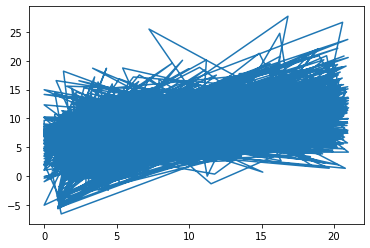

In [231]:
print("actual target value" , "predicted value\n")
print(y2_test, test_pred2)
plt.plot(y2_test, test_pred2)

In [232]:
#mean square error
test_mse = mean_squared_error(y2_test, test_pred2)
#mean absolute error
test_mae = mean_absolute_error(y2_test,test_pred2)
#root mean square error
test_rmse = np.round(np.sqrt(test_mse),2)
                     
print('Mean Absolute Error: %0.2f' % test_mse)
print('Mean Squared Error: %0.2f' % test_mae)
print('Root Mean Squared Error: %0.2f' % test_rmse)

Mean Absolute Error: 27.12
Mean Squared Error: 4.43
Root Mean Squared Error: 5.21
